# 02 — Training Model KNN (3 Fitur: Accel + Gyro + BPM)

**Prasyarat:** Jalankan `01_eksplorasi_data.ipynb` terlebih dahulu.
File `data/processed/dataset_clean.csv` harus sudah tersedia.

**Sumber data:** Dataset dikumpulkan menggunakan `src/collect_participants.py`.
Label aktivitas (DUDUK/BERJALAN/BERLARI) diinput **manual oleh operator** per sesi,
bukan dari ESP32. ESP32 hanya mengirim data sensor mentah.


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, ConfusionMatrixDisplay)

from config import (FEATURES, TARGET, CLASSES, CLASS_MAP, BPM_MED_PATH,
                    K_NEIGHBORS, KNN_METRIC, KNN_WEIGHTS, MODEL_PATH, SCALER_PATH)
from utils  import (load_and_clean_dataset, impute_bpm, normalize_features,
                    encode_labels, remove_outliers, get_logger)

logger = get_logger('notebook_02')
sns.set_theme(style='whitegrid')
print('Fitur yang digunakan:', FEATURES)

Fitur yang digunakan: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Muat Dataset Bersih

In [2]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df_raw = load_and_clean_dataset(CLEAN_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Kolom: {df_raw.columns.tolist()}')

print('\n=== DISTRIBUSI KELAS ===')
print(df_raw[TARGET].value_counts().to_string())

print('\n=== STATISTIK BPM per KELAS (sebelum imputasi) ===')
print(f'{"Kelas":<12} {"N":>6} {"BPM=0":>8} {"% Valid":>9} {"Median BPM":>12}')
print('─' * 52)
for cls in CLASSES:
    sub   = df_raw[df_raw[TARGET]==cls]
    valid = sub[sub['bpm']>0]['bpm']
    pct   = len(valid)/len(sub)*100
    med   = valid.median() if len(valid)>0 else 0
    print(f'{cls:<12} {len(sub):>6} {len(sub)-len(valid):>8} {pct:>8.1f}% {med:>12.0f}')


Shape: (13214, 8)
Kolom: ['accel_stddev', 'gyro_stddev', 'bpm', 'activity', 'bpm_filled', 'participant_id', 'participant_no', 'received_at']

=== DISTRIBUSI KELAS ===
activity
BERJALAN    4459
DUDUK       4439
BERLARI     4316

=== STATISTIK BPM per KELAS (sebelum imputasi) ===
Kelas             N    BPM=0   % Valid   Median BPM
────────────────────────────────────────────────────
DUDUK          4439      414     90.7%           80
BERJALAN       4459      364     91.8%           86
BERLARI        4316      149     96.5%          130


## 2. Imputasi BPM = 0

BPM = 0 (sensor tidak terbaca) diisi median per kelas dari data training.

In [3]:
df, bpm_medians = impute_bpm(df_raw, fit=True)

# Simpan bpm_medians untuk server_knn.py
joblib.dump(bpm_medians, BPM_MED_PATH)
print('BPM medians disimpan:', BPM_MED_PATH)
print(bpm_medians)

# Hapus outlier
df = remove_outliers(df)
df = encode_labels(df)
print('Dataset setelah preprocessing:', df.shape)

BPM Median per kelas (untuk imputasi):
  DUDUK: 80 bpm
  BERJALAN: 86 bpm
  BERLARI: 130 bpm
  _global: 93 bpm
BPM medians disimpan: c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl
{'DUDUK': 80, 'BERJALAN': 86, 'BERLARI': 130, '_global': 93}
Dataset setelah preprocessing: (13149, 9)


## 3. Normalisasi 3 Fitur (accel_stddev, gyro_stddev, bpm_filled)

In [4]:
print('Sebelum normalisasi:')
print(df[FEATURES].describe().round(4))

df, scaler = normalize_features(df, fit=True)

print('\nSetelah normalisasi (min=0, max=1):')
print(df[FEATURES].describe().round(4))

Sebelum normalisasi:
       accel_stddev  gyro_stddev  bpm_filled
count    13149.0000   13149.0000  13149.0000
mean         0.0677      27.6976    100.9255
std          0.0682      27.4677     32.6667
min          0.0033       0.0175     30.0000
25%          0.0112       3.8873     79.0000
50%          0.0419      18.5104     91.0000
75%          0.1058      45.2329    120.0000
max          0.3137     124.3110    196.0000

Setelah normalisasi (min=0, max=1):
       accel_stddev  gyro_stddev  bpm_filled
count    13149.0000   13149.0000  13149.0000
mean         0.2076       0.2227      0.4273
std          0.2196       0.2210      0.1968
min          0.0000       0.0000      0.0000
25%          0.0256       0.0311      0.2952
50%          0.1245       0.1488      0.3675
75%          0.3303       0.3638      0.5422
max          1.0000       1.0000      1.0000


## 4. Split Train / Test

In [5]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Total  : {len(X)} sampel')
print(f'Train  : {X_train.shape[0]} sampel (80%)')
print(f'Test   : {X_test.shape[0]} sampel (20%)')
print()

# Tabel distribusi per kelas — termasuk rata-rata nilai BPM (setelah normalisasi)
# Catatan: BPM di sini sudah ternormalisasi (0-1), bukan nilai asli BPM
# Indeks fitur: 0=accel_stddev, 1=gyro_stddev, 2=bpm_filled
print(f'{"Kelas":<12} {"Train":>7} {"Test":>7} {"Total":>7} '
      f'{"BPM_norm mean (train)":>22}')
print('─' * 60)
for cls in CLASSES:
    n_train = sum(y_train == cls)
    n_test  = sum(y_test  == cls)
    # Rata-rata nilai BPM yang sudah dinormalisasi pada data training kelas ini
    bpm_mean_norm = X_train[y_train == cls, 2].mean() if n_train > 0 else 0
    print(f'{cls:<12} {n_train:>7} {n_test:>7} {n_train+n_test:>7} '
          f'{bpm_mean_norm:>22.4f}')

print()
print('Catatan: Kolom BPM_norm adalah nilai bpm_filled setelah MinMaxScaler.')
print('Nilai 0.0 = BPM terendah di dataset, 1.0 = BPM tertinggi.')
print('Fitur BPM digunakan sebagai fitur ke-3 dalam KNN, bukan sebagai label/kelas.')


Total  : 13149 sampel
Train  : 10519 sampel (80%)
Test   : 2630 sampel (20%)

Kelas          Train    Test   Total  BPM_norm mean (train)
────────────────────────────────────────────────────────────
DUDUK           3550     888    4438                 0.3296
BERJALAN        3567     892    4459                 0.3553
BERLARI         3402     850    4252                 0.6037

Catatan: Kolom BPM_norm adalah nilai bpm_filled setelah MinMaxScaler.
Nilai 0.0 = BPM terendah di dataset, 1.0 = BPM tertinggi.
Fitur BPM digunakan sebagai fitur ke-3 dalam KNN, bukan sebagai label/kelas.


## 5. Hyperparameter Tuning — Cari K Terbaik

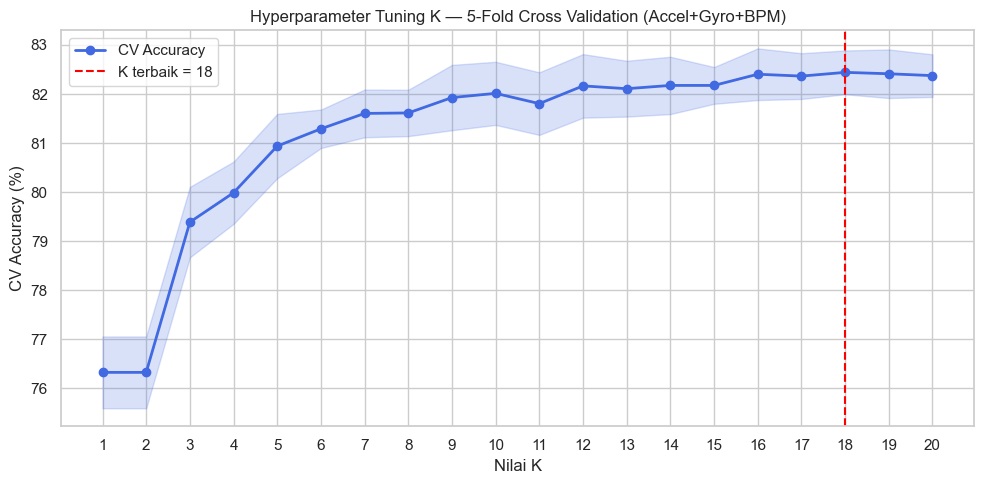

=== HASIL CV ACCURACY SEMUA NILAI K ===
   K   CV Acc (%)    Std (%)   Keterangan
──────────────────────────────────────────
   1        76.33       0.73             
   2        76.33       0.73             
   3        79.39       0.72             
   4        79.99       0.63             
   5        80.94       0.65             
   6        81.29       0.39             
   7        81.60       0.49             
   8        81.61       0.47             
   9        81.93       0.67             
  10        82.01       0.64             
  11        81.80       0.64             
  12        82.17       0.65             
  13        82.11       0.57             
  14        82.18       0.58             
  15        82.18       0.37             
  16        82.40       0.53             
  17        82.37       0.47             
  18        82.44       0.45    ← TERBAIK
  19        82.41       0.49             
  20        82.37       0.43             

✅ K terbaik  : 18
   CV Accuracy: 

In [6]:
k_range   = range(1, 21)
cv_scores = []; cv_std = []
kfold     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric=KNN_METRIC, weights=KNN_WEIGHTS)
    scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores.mean()); cv_std.append(scores.std())

cv_scores = np.array(cv_scores); cv_std = np.array(cv_std)
best_k    = list(k_range)[np.argmax(cv_scores)]
best_score= cv_scores.max()

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), cv_scores*100, 'o-', color='royalblue', lw=2, label='CV Accuracy')
plt.fill_between(list(k_range), (cv_scores-cv_std)*100, (cv_scores+cv_std)*100,
                 alpha=0.2, color='royalblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K terbaik = {best_k}')
plt.xlabel('Nilai K'); plt.ylabel('CV Accuracy (%)'); plt.legend()
plt.title('Hyperparameter Tuning K — 5-Fold Cross Validation (Accel+Gyro+BPM)')
plt.xticks(list(k_range)); plt.tight_layout()
plt.savefig('../data/processed/tuning_k_3fitur.png', dpi=150); plt.show()

# Tampilkan tabel lengkap semua nilai K
print('=== HASIL CV ACCURACY SEMUA NILAI K ===')
print(f'{"K":>4} {"CV Acc (%)":>12} {"Std (%)":>10} {"Keterangan":>12}')
print('─' * 42)
for i, k in enumerate(k_range):
    ket = '← TERBAIK' if k == best_k else ''
    print(f'{k:>4} {cv_scores[i]*100:>12.2f} {cv_std[i]*100:>10.2f} {ket:>12}')

print(f'\n✅ K terbaik  : {best_k}')
print(f'   CV Accuracy: {best_score*100:.2f}%')
print(f'\nAlasan K={best_k} dipilih:')
print(f'  → K={best_k} menghasilkan CV accuracy tertinggi ({best_score*100:.2f}%)')
print(f'    dari pencarian K=1 sampai K=20 menggunakan 5-Fold Stratified CV.')
print(f'  → Nilai K bukan hardcode — ditentukan otomatis berdasarkan data Anda.')
print(f'  → Jika dataset berubah (tambah data), jalankan ulang cell ini untuk')
print(f'    mendapatkan K optimal yang baru.')


## 6. Training Model Final

In [7]:
USE_K = best_k  # bisa override: USE_K = K_NEIGHBORS

knn = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print('K =', USE_K, '| Test Accuracy:', round(acc*100, 2), '%')

K = 18 | Test Accuracy: 83.69 %


## 7. Classification Report

In [8]:
# ─────────────────────────────────────────────────────────────────
# PENJELASAN PENTING:
# Classification report menampilkan metrik per KELAS AKTIVITAS
# (DUDUK, BERJALAN, BERLARI), bukan per fitur.
#
# BPM adalah FITUR INPUT (variabel X), bukan LABEL OUTPUT (variabel y).
# Sehingga BPM tidak muncul sebagai baris di classification report —
# ini benar secara konsep, bukan kekurangan.
#
# Kontribusi BPM sebagai fitur ditunjukkan di section 9 (perbandingan
# akurasi 2 fitur vs 3 fitur).
# ─────────────────────────────────────────────────────────────────

print('=== CLASSIFICATION REPORT — 3 FITUR (Accel + Gyro + BPM) ===')
print('Label pada report = kelas aktivitas (output/y), bukan nama fitur.')
print('BPM adalah fitur input (X), kontribusinya diukur di section 9.')
print()
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

# Tambahan: rata-rata BPM (normalized) per kelas pada data test
print('=== RATA-RATA NILAI BPM (normalized) pada DATA TEST per KELAS ===')
print(f'{"Kelas":<12} {"N test":>8} {"BPM_norm mean":>15} {"BPM_norm std":>14}')
print('─' * 52)
for cls in CLASSES:
    mask = y_test == cls
    bpm_vals = X_test[mask, 2]  # indeks 2 = bpm_filled
    print(f'{cls:<12} {mask.sum():>8} {bpm_vals.mean():>15.4f} {bpm_vals.std():>14.4f}')
print()
print('Tabel di atas menunjukkan bahwa nilai BPM berbeda antar kelas,')
print('membuktikan BPM berkontribusi sebagai fitur diskriminatif.')


=== CLASSIFICATION REPORT — 3 FITUR (Accel + Gyro + BPM) ===
Label pada report = kelas aktivitas (output/y), bukan nama fitur.
BPM adalah fitur input (X), kontribusinya diukur di section 9.

              precision    recall  f1-score   support

       DUDUK     0.7683    0.8105    0.7889       892
    BERJALAN     0.8401    0.8776    0.8585       850
     BERLARI     0.9139    0.8243    0.8668       888

    accuracy                         0.8369      2630
   macro avg     0.8408    0.8375    0.8380      2630
weighted avg     0.8407    0.8369    0.8377      2630

=== RATA-RATA NILAI BPM (normalized) pada DATA TEST per KELAS ===
Kelas          N test   BPM_norm mean   BPM_norm std
────────────────────────────────────────────────────
DUDUK             888          0.3272         0.1314
BERJALAN          892          0.3603         0.1303
BERLARI           850          0.6059         0.1912

Tabel di atas menunjukkan bahwa nilai BPM berbeda antar kelas,
membuktikan BPM berkontribusi seb

## 8. Confusion Matrix

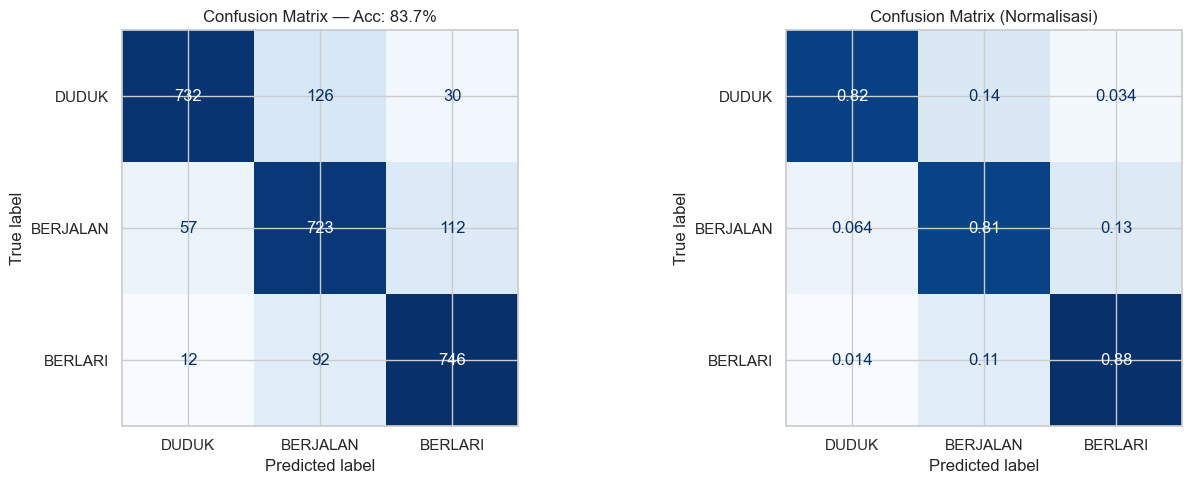

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Acc: ' + str(round(acc*100,1)) + '%')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3), display_labels=CLASSES).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalisasi)')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_3fitur.png', dpi=150)
plt.show()

## 9. Kontribusi BPM — Bandingkan 2 vs 3 Fitur

=== PERBANDINGAN KOMBINASI FITUR ===
                   fitur       acc
Accel+Gyro+BPM (3 fitur) 83.688213
    Accel+Gyro (2 fitur) 77.794677
      BPM saja (1 fitur) 55.551331


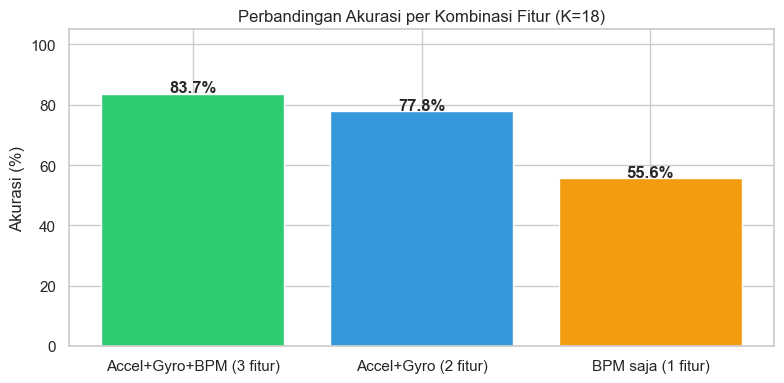


Penambahan BPM meningkatkan akurasi sebesar 5.89 %


In [10]:
results_feat = []

# 3 fitur
results_feat.append({'fitur': 'Accel+Gyro+BPM (3 fitur)', 'acc': acc*100})

# 2 fitur: Accel+Gyro
knn2 = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn2.fit(X_train[:, :2], y_train)
acc2 = accuracy_score(y_test, knn2.predict(X_test[:, :2]))
results_feat.append({'fitur': 'Accel+Gyro (2 fitur)', 'acc': acc2*100})

# BPM saja
knn_b = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn_b.fit(X_train[:, 2:3], y_train)
acc_b = accuracy_score(y_test, knn_b.predict(X_test[:, 2:3]))
results_feat.append({'fitur': 'BPM saja (1 fitur)', 'acc': acc_b*100})

df_res = pd.DataFrame(results_feat).sort_values('acc', ascending=False)
print('=== PERBANDINGAN KOMBINASI FITUR ===')
print(df_res.to_string(index=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(df_res['fitur'], df_res['acc'],
               color=['#2ecc71', '#3498db', '#f39c12'])
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi per Kombinasi Fitur (K=' + str(USE_K) + ')')
plt.ylim(0, 105)
for bar, val in zip(bars, df_res['acc']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(round(val,1))+'%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

gain = acc*100 - acc2*100
print('\nPenambahan BPM meningkatkan akurasi sebesar', round(gain,2), '%')

## 10. Simpan Model, Scaler, BPM Medians

In [11]:
joblib.dump(knn,         MODEL_PATH)
joblib.dump(scaler,      SCALER_PATH)
joblib.dump(bpm_medians, BPM_MED_PATH)

print('Model  ->', MODEL_PATH)
print('Scaler ->', SCALER_PATH)
print('BPM    ->', BPM_MED_PATH)
print()
print('=== RINGKASAN MODEL ===')
print('Algoritma :', 'KNN')
print('K         :', USE_K)
print('Fitur     :', FEATURES)
print('BPM med   :', bpm_medians)
print('Test Acc  :', round(acc*100, 2), '%')

Model  -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\knn_model.pkl
Scaler -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\scaler.pkl
BPM    -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl

=== RINGKASAN MODEL ===
Algoritma : KNN
K         : 18
Fitur     : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
BPM med   : {'DUDUK': 80, 'BERJALAN': 86, 'BERLARI': 130, '_global': 93}
Test Acc  : 83.69 %


## 11. Perbandingan Metric Jarak (Opsional)

In [12]:
results = []
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for w in ['uniform', 'distance']:
        knn_tmp = KNeighborsClassifier(n_neighbors=USE_K, metric=metric, weights=w)
        scores  = cross_val_score(knn_tmp, X_train, y_train, cv=kfold, scoring='accuracy')
        results.append({'metric':metric,'weights':w,
                         'cv_mean':round(scores.mean()*100,2),
                         'cv_std':round(scores.std()*100,2)})
df_m = pd.DataFrame(results).sort_values('cv_mean', ascending=False)
print('=== Perbandingan Konfigurasi KNN ===')
print(df_m.to_string(index=False))

=== Perbandingan Konfigurasi KNN ===
   metric  weights  cv_mean  cv_std
manhattan  uniform    82.75    0.44
manhattan distance    82.64    0.51
euclidean distance    82.44    0.45
euclidean  uniform    82.43    0.54
chebyshev  uniform    82.36    0.53
chebyshev distance    82.18    0.58
